# Setup

In [110]:
import requests
from bs4 import BeautifulSoup
from typing import List, Optional, TypedDict
from dotenv import load_dotenv
from pydantic import BaseModel, Field, ConfigDict
from langchain.chat_models import init_chat_model


load_dotenv()
llm = init_chat_model('gpt-4.1-mini')
extract_model_llm = init_chat_model('gpt-4o') 

# Schemas

In [111]:
from typing import List, Optional, Union, Literal
from pydantic import BaseModel, Field, ConfigDict

# OpenAI Strict 모드를 위한 공통 설정
STRICT_CONF = ConfigDict(extra='forbid')

# 비판 결과 스키마
class CriticReview(BaseModel):
    model_config = STRICT_CONF
    is_perfect: bool = Field(description="논리적 오류가 전혀 없으면 True")
    critique_points: List[str] = Field(default=[], description="오류 지점 및 수정 요구사항 목록")
    severity: Literal["CRITICAL", "MINOR", "NONE"] = Field(description="오류의 심각도")
    
class OptionSummary(BaseModel):
    model_config = STRICT_CONF
    option_name: str
    brief_description: str # 예: "스타벅스 50% 할인 + 편의점 7% 할인"

class OptionsPreview(BaseModel):
    model_config = STRICT_CONF
    summaries: List[OptionSummary]

# 판단 노드(Decision Node) 전용 스키마
class FlowDecision(BaseModel):
    model_config = STRICT_CONF
    # Literal 타입으로 'direct'와 'selection'만 허용
    decision: Literal["direct", "selection"] = Field(
        description="단일 카드면 'direct', 선택이 필요하면 'selection'"
    )
    options: List[str] = Field(default=[], description="선택형일 경우 후보군 카드 이름 리스트")
    reason: str = Field(description="그렇게 판단한 이유")

# 1. 최하위 계층
class PerformanceTier(BaseModel):
    model_config = STRICT_CONF
    tier_min: int
    limit: int

class BenefitLimit(BaseModel):
    model_config = STRICT_CONF
    monthly: Optional[int] = None
    yearly: Optional[int] = None
    monthly_performance_tiers: Optional[List[PerformanceTier]] = None

class BenefitCondition(BaseModel):
    model_config = STRICT_CONF
    min_performance: int = 0
    min_per_transaction: Optional[int] = Field(None, description="혜택을 받기 위한 건당 최소 결제 금액")
    payment_method: str = "ANY"
    is_overseas_only: Optional[bool] = None
    location_exclude: Optional[List[str]] = None
    per_transaction_cap: Optional[int] = None
    platform: Optional[str] = None
    domestic_only: Optional[bool] = None

class PerformanceImpact(BaseModel):
    model_config = STRICT_CONF
    counts_toward_performance: bool
    is_all_or_nothing_exclusion: bool = False
    comment: Optional[str] = None

CardCategory = Literal[
    "FOOD",                   # 1. 음식점
    "DELIVERY",               # 2. 배달
    "CAFE_BAKERY",            # 3. 카페/베이커리
    "MEDICAL",                # 4. 병원/약국
    "EDUCATION",              # 5. 학원/교육
    "PARKING_LOT",            # 6. 주차장
    "OIL",                    # 7. 주유소
    "TRANSPORTATION",         # 8. 대중교통
    "TELECOM_UTILITY",        # 9. 통신/공과금
    "CONVENIENCE",            # 10. 편의점
    "SHOPPING",               # 11. 쇼핑 (마트, 백화점 등)
    "CULTURE_ENTERTAINMENT",  # 12. 문화/엔터 (영화, 테마파크 등)
    "SUBSCRIPTION",           # 13. 구독서비스
    "OVERSEAS",               # 14. 해외 결제
    "TRAVEL",                 # 15. 여행 (항공, 숙박 등)
    "AIRPORT_LOUNGE",         # 16. 공항 라운지
    "OTHER"                   # 17. 기타
]

BenefitType = Literal[
    "PERCENT_DISCOUNT",    # % 할인
    "KRW_DISCOUNT",        # 원 단위 할인
    "CASHBACK",            # 현금 캐시백
    "POINT_ACCUMULATION",  # 포인트 적립
    "FEE_WAIVER",          # 수수료 면제
    "FREE_ACCESS"          # 무료 이용 (라운지 등)
]
BenefitUnit = Literal["PERCENT", "KRW", "COUNT"]

class CardBenefit(BaseModel):
    model_config = ConfigDict(extra='forbid') 
    
    benefit_id: str = Field(description="혜택의 고유 ID (예: COFFEE_50)")
    category: CardCategory = Field(description="DB 매핑용 카테고리")
    merchant: Optional[List[str]] = Field(default=None, description="혜택 가맹점 리스트")
    type: BenefitType = Field(description="혜택의 종류 (객관식)")
    value: float = Field(description="혜택의 수치 (10.0, 5000.0 등)")
    unit: BenefitUnit = Field(description="수치의 단위 (PERCENT, KRW, COUNT)")
    
    conditions: 'BenefitCondition'
    limits: 'BenefitLimit'
    performance_impact: 'PerformanceImpact'

# 2. 중간 계층 (Logic 파트)
class PerformanceLogic(BaseModel):
    model_config = STRICT_CONF
    calculation_period: str
    global_performance_exclusion: List[str]
    domestic_only_performance: bool

class GracePeriodLogic(BaseModel):
    model_config = STRICT_CONF
    duration: str
    default_benefit_tier: str
    daily_life_limit: int
    air_dutyfree_limit: int
    transport_limit: int

# 3. 최상위 계층 (Root)
class CardDataSchema(BaseModel):
    model_config = STRICT_CONF
    card_id: str
    card_name: str
    issuer: str
    card_type: Literal["CREDIT", "CHECK"] = Field(description="카드의 종류 (CREDIT 또는 CHECK)")
    critical_warning: str
    performance_logic: PerformanceLogic
    benefits: List[CardBenefit]
    grace_period_logic: GracePeriodLogic

class CombinedDecision(BaseModel):
    decision: Literal["direct", "selection"]
    options: List[str] = Field(default=[], description="선택형일 경우 후보군 이름")
    summaries: List[OptionSummary] = Field(default=[], description="선택지별 요약 정보")
    reason: str

In [112]:
from typing import List, Optional, Union, Literal, TypedDict, Any

class State(TypedDict):
    # 1. 원본 식별 정보 (절대 수정 금지)
    card_id: str
    base_card_name: str  # 크롤링 직후 저장하는 '진짜' 원본 이름 (예: 삼성카드 6)
    
    # 2. 분석 과정 데이터
    card_name: Optional[str] # 진행 중인 이름 (예: 삼성카드 6 (선택옵션 1))
    card_type: Optional[Literal["CREDIT", "CHECK"]] 
    
    # 텍스트 데이터
    raw_text: Optional[str]
    formatted_md: Optional[str]  
    
    # 분석 및 라우팅 상태
    decision: Optional[Literal["direct", "selection"]]    
    options_list: List[str]        
    summaries: List[OptionSummary] 
    selected_option: Optional[str] # 사용자가 선택한 패키지명 (예: 선택옵션 1)
    
    # 검증 및 결과
    critic_feedback: Optional[dict]
    output_json: Optional[dict]
    
    # 카운터 및 플래그
    iteration_count: int          
    is_manually_fixed: Optional[bool]

# Nodes

In [113]:
from typing import TypedDict, List, Optional
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
import json
from server.database.connection import get_db_conn
import os
import requests
from bs4 import BeautifulSoup
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv()

# OpenAI 클라이언트 설정
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))


# 시작: 카드 정보 받아오기
def node_ingest_card_data(state: State):
    card_id = state["card_id"]
    print(f"[Node: Ingest] 카드 ID {card_id} 크롤링 시작...")

    url = f"https://api.card-gorilla.com:8080/v1/cards/{card_id}"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36...",
    }

    # 실제 요청 수행
    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        raise Exception(f"데이터 로드 실패: {response.status_code}")

    data = response.json()

    # 텍스트 정제 (BeautifulSoup 활용)
    benefit_segments = []
    for benefit in data.get("key_benefit", []):
        soup = BeautifulSoup(benefit.get("info", ""), "html.parser")
        benefit_segments.append(
            f"[{benefit.get('title')}]\n{soup.get_text(separator=' ').strip()}"
        )

    return {"base_card_name": data.get("name"), "card_name": data.get("name"), "raw_text": "\n\n".join(benefit_segments)}


# Node 0: 받아온 정보를 마크다운 형식으로 정제
def node_format_markdown(state: State):
    print("[Node 0: Format] 원문을 마크다운 구조로 정제 중...")
    
    system_msg = """너는 금융 상품 설명서 전문 편집자야. 
    네 임무는 입력된 '비정형 카드 혜택 텍스트'를 데이터 누락 없이 '구조화된 마크다운(Markdown)' 문서로 재구성하는 것이야.

    [준수 규칙]
    1. 전량 보존(Lossless): 원문에 포함된 모든 수치, 조건, 유의사항, 예외 조항을 단 하나도 생략하거나 요약하지 마.
    2. 표 구조화(Table First): 수치나 조건이 나열된 구간은 마크다운 테이블(|---|) 형식을 사용해.
    3. 혜택별 헤딩 분리 (가장 중요): 모든 혜택을 하나의 거대한 표로 뭉뚱그리지 마! 반드시 혜택의 카테고리(예: 편의점, 카페, 통신요금 등)마다 '## [카테고리명]'으로 독립된 헤딩을 작성하고, 그 아래에 해당 혜택의 표나 유의사항을 적어.
    4. 항목 구분: 전월 실적 제외 대상 등 줄글 정보는 불렛 포인트(*)를 사용해.
    5. 원문 강조: '실적 제외', '한도 차등 적용' 등 독소 조항 키워드는 **볼드** 처리해."""
    
    response = llm.invoke([
        {"role": "system", "content": system_msg},
        {"role": "user", "content": f"원문 텍스트:\n{state['raw_text']}"}
    ])
    
    return {"formatted_md": response.content}

# Node A: 마크다운으로 정제된 텍스트를 벡터화하여 DB에 저장
def get_embedding(text):
    response = client.embeddings.create(
        input=text,
        model="text-embedding-3-small"
    )
    return response.data[0].embedding
def node_vector_db_commit(state: State):
    card_id = state["card_id"]
    card_name = state.get("card_name", "알 수 없는 카드")
    formatted_md = state.get("formatted_md", "")
    
    print(f"[Node: Vector DB] '{card_name}' 벡터화 및 저장 시작...")

    # 카드사 추출 
    completion = client.chat.completions.create(
        model="gpt-4.1-mini", 
        messages=[
            {
                "role": "system", 
                "content": "당신은 팩트 기반 정보 추출 전문가입니다. 제공된 신용카드 약관 텍스트를 꼼꼼히 읽고, 해당 카드를 발급한 '카드회사 이름(예: KB국민카드, 신한카드, 현대카드 등)'만 찾아내어 단답형으로 출력하세요. 이름만 보고 임의로 유추하는 것을 엄격히 금지합니다. 텍스트 내에서 증거를 찾을 수 없다면 반드시 '알 수 없는 회사'라고 출력하세요."
            },
            {
                "role": "user", 
                "content": f"카드 원문 텍스트: {formatted_md[:3000]}"
            }
        ],
        temperature=0 
    )
    card_company = completion.choices[0].message.content.strip()

    # 16개 카테고리 키워드 정의
    keywords_map = {
        "FOOD": ["음식점", "식당", "외식", "패밀리레스토랑"],
        "DELIVERY": ["배달", "배달의민족", "요기요", "쿠팡이츠"],
        "CAFE_BAKERY": ["카페", "스타벅스", "베이커리", "커피", "디저트", "투썸", "이디야", "파리바게뜨", "뚜레쥬르"],
        "MEDICAL": ["병원", "약국", "치과", "한의원", "의료", "건강검진"],
        "EDUCATION": ["학원", "교육", "학습지", "서점", "도서", "강의", "유치원"],
        "PARKING_LOT": ["주차장", "주차", "발레파킹"],
        "OIL": ["주유", "GSCALTEX", "S-OIL", "현대오일뱅크", "SK에너지", "충전소"],
        "TRANSPORTATION": ["대중교통", "버스", "지하철", "택시", "철도", "KTX", "SRT", "K-패스"],
        "TELECOM_UTILITY": ["통신", "SKT", "KT", "LGU+", "이동통신", "공과금", "관리비", "가스비", "전기요금"],
        "CONVENIENCE": ["편의점", "CU", "GS25", "세븐일레븐", "이마트24", "다이소", "올리브영"],
        "SHOPPING": ["마트", "이마트", "홈플러스", "롯데마트", "백화점", "아울렛", "쇼핑", "쿠팡", "온라인쇼핑", "오픈마켓", "11번가"],
        "CULTURE_ENTERTAINMENT": ["영화", "CGV", "메가박스", "롯데시네마", "문화", "공연", "전시", "테마파크", "놀이공원"],
        "SUBSCRIPTION": ["구독", "넷플릭스", "유튜브", "프리미엄", "디즈니플러스", "멜론", "스트리밍"],
        "OVERSEAS": ["해외", "직구", "가맹점(해외)", "아마존", "알리", "테무"],
        "TRAVEL": ["항공", "항공권", "면세점", "호텔", "숙박", "여행사", "렌터카", "야놀자", "여기어때"],
        "AIRPORT_LOUNGE": ["라운지", "공항서비스", "마티나", "스카이허브", "인천공항", "공항발레파킹", "더라운지", "라운지키"]
    }

    try:
        with get_db_conn() as conn:
            with conn.cursor() as cur:
                
                # 마크다운 문서를 혜택 단위(##)로 쪼개서 저장 (검색 품질 상승을 위함)
                # "## (선택형 팩 이름)" 등으로 계층화했기 때문에 이 기준으로 쪼개면 훌륭한 Chunking이 됩니다.
                chunks = formatted_md.split("## ")
                
                for chunk in chunks:
                    if len(chunk.strip()) < 10:  # 너무 짧은 텍스트(공백 등)는 무시
                        continue
                        
                    # 카테고리 분류 로직 (Chunk 텍스트 기반)
                    found_categories = [
                        cat for cat, kws in keywords_map.items() 
                        if any(kw in chunk for kw in kws)
                    ]
                    final_category = found_categories[0] if found_categories else "OTHER"

                    # 텍스트 병합 및 임베딩
                    full_text = f"카드명: {card_name} | 내용: {chunk.strip()}"
                    embedding = get_embedding(full_text)

                    # DB Insert
                    cur.execute("""
                        INSERT INTO card_benefit_vectors 
                        (card_id, card_company, card_name, benefit_category, content, embedding)
                        VALUES (%s, %s, %s, %s, %s, %s)
                    """, (
                        card_id, card_company, card_name, 
                        final_category, full_text, embedding
                    ))
                
                conn.commit()
                print(f"[Node: Vector DB] '{card_name}' Vector DB 저장 완료!")

    except Exception as e:
        print(f"Vector DB 오류 발생: {e}")
        
    return {} # State 자체를 수정할 필요는 없으므로 빈 딕셔너리 반환





def node_decide_and_summarize(state: State):
    print("[Node: Decide & Summarize] 카드 타입 판단 및 요약 생성 중...")
    
    # raw_text 대신 formatted_md를 사용하여 정확도 향상
    input_text = state.get("formatted_md") or state.get("raw_text")

    structured_llm = llm.with_structured_output(CombinedDecision)
    prompt = ChatPromptTemplate.from_template(
        """
        입력된 카드 혜택 마크다운 문서를 분석하여 '선택형 패키지' 유무를 판단하라.
        
        [판단 기준]
        - 선택 혜택: 삼성카드 taptap O처럼 '라이프스타일 패키지 1~6' 중 하나를 골라야 하거나, '쇼핑 7% 할인 vs 1% 적립' 중 하나를 선택해야 하는 경우를 엄격하게 selection으로 분류해.
        - 단일 카드: 모든 혜택이 공통적으로 적용되거나, 단순히 카테고리가 나열된 경우.

        입력된 마크다운 문서를 분석하여 '사용자가 하나를 골라야 하는 패키지 옵션'의 상세 목록을 추출하라.
    
            [추출 규칙]
            1. '패키지1', '옵션A' 처럼 명확하게 구분된 선택지들을 각각 하나의 OptionSummary로 만든다.
            2. summaries의 option_name에는 '패키지 1' 또는 '스타벅스 50% + 오픈마켓 7%' 처럼 구체적인 이름을 적는다.
            3. '대중교통 10%' 처럼 모든 패키지에 공통으로 적용되는 혜택은 summaries에 넣지 않는다. (이것들은 나중에 ExtractData에서 처리함)

        [텍스트]: {text}
        """
    )

    response = structured_llm.invoke(prompt.format(text=input_text))

    # 후처리: options_list가 비어있는데 decision이 selection인 경우 방지
    decision = response.decision
    if decision == "selection" and not response.options:
        decision = "direct"

    return {
        "decision": decision,
        "options_list": response.options,
        "summaries": response.summaries
    }

# 라우터
# '선택'이 필요하면 요약 노드로, 아니면 추출 노드로
def router(state: State):
    # 의사결정이 'selection'이거나, 
    # 혹은 decision은 'direct'지만 LLM이 요약된 옵션들을 찾아낸 경우
    if state.get("decision") == "selection" or (state.get("options_list") and len(state.get("options_list")) > 0):
        print(f"[Router] 선택지 {len(state['options_list'])}개가 발견되었습니다. 사용자 선택 노드로 이동합니다.")
        return "SummarizeOptions"
    
    print("[Router] 단일 카드 상품으로 판단되었습니다. 즉시 추출을 시작합니다.")
    return "ExtractData"



# 선택형 카드의 경우, 사용자에게 선택지를 보여주고 입력을 기다리는 노드
def node_wait_user_choice(state: State):
    # 1. 요약된 내용 출력 (summaries가 문자열이라면 그대로 출력)
    print("\n[AI 요약 리포트]")
    for i, s in enumerate(state["summaries"], 1):
        print(f"{i}. {s.option_name}: {s.brief_description}")
    # 2. 인터럽트 발생 (사용자 입력 대기)
    # CLI 환경: 여기서 멈추고 입력을 기다림
    user_input = interrupt(
        {
            "question": "분석할 패키지 번호(1~6)나 이름을 입력해주세요.",
            "options": state["options_list"],
        }
    )

    # 3. 입력값 처리 (번호인지 이름인지 판단)
    selected = None

    # 입력이 숫자(1, 2, 3...)인 경우 처리
    if str(user_input).isdigit():
        idx = int(user_input) - 1
        if 0 <= idx < len(state["options_list"]):
            selected = state["options_list"][idx]
            print(f"{idx+1}번({selected})이 선택되었습니다.")

    # 입력이 이름인 경우 처리
    if not selected:
        selected = user_input
        print(f"'{selected}' 패키지가 선택되었습니다.")

    # 4. 다음 단계를 위해 State 업데이트
    # decision을 'direct'로 바꿔야 추출 노드로 넘어감.
    return {
        "decision": "direct",
        "selected_option": selected,
        "card_name": f"{state['base_card_name']} ({selected})",  
    }




# Node : JSON 추출 노드
def node_extract_data(state: State):
    print(f"[Node: Extract] '{state['card_name']}' 데이터 정밀 분석 및 JSON 생성 중...")

    structured_llm = extract_model_llm.with_structured_output(CardDataSchema)

    selected_info = (
        f"사용자가 선택한 옵션: {state.get('selected_option', '기본/단일 패키지')}"
    )

    feedback_section = ""
    if state.get("critic_feedback") and not state["critic_feedback"].get("is_perfect"):
        points = "\n- ".join(state["critic_feedback"].get("critique_points", []))
        feedback_section = f"\n\n [비판자 피드백 반영 필요]:\n- {points}"

    system_msg = f"""너는 신용카드 약관 분석 전문가야. 아래 규칙을 엄격히 준수해.

    [중요] 카드 이름 관련: 
    현재 분석 중인 카드의 공식 명칭은 '{state['card_name']}'이다. 
    JSON의 card_name 필드에는 반드시 이 이름을 그대로 사용하고, 뒤에 선택된 옵션이 있다면 괄호로 병기하라. 
    예: '삼성카드 iD ON (선택옵션 A)'

    [데이터 규격 규칙]
    - category: FOOD, DELIVERY, CAFE_BAKERY, MEDICAL, EDUCATION, PARKING_LOT, OIL, TRANSPORTATION, TELECOM_UTILITY, CONVENIENCE, SHOPPING, CULTURE_ENTERTAINMENT, SUBSCRIPTION, OVERSEAS, TRAVEL, AIRPORT_LOUNGE, OTHER 중 하나만 선택.
    - type: PERCENT_DISCOUNT, KRW_DISCOUNT, CASHBACK, POINT_ACCUMULATION, FEE_WAIVER, FREE_ACCESS 중 하나만 선택.
    - unit: PERCENT, KRW, COUNT 중 하나만 선택.
    - card_type 추출: 카드의 연회비 유무나 결제 방식을 보고 CREDIT(신용) 또는 CHECK(체크) 중 하나를 정확히 판별해.

    [추출 지시]
    1. {selected_info}에 해당하는 혜택 정보를 집중적으로 분석해.
    2. '전월 실적 제외 항목'을 global_performance_exclusion에 빠짐없이 나열해.
    3. 특히 '할인 받은 결제 건이 실적에서 제외되는지' 여부를 performance_impact의 is_all_or_nothing_exclusion에 정확히 기록해.
    4. 실적 구간별로 한도가 다르다면 monthly_performance_tiers에 모든 구간을 명시해.{feedback_section}
    5. '건당 최소 결제 금액' 조건이 있는지 텍스트에서 눈을 부릅뜨고 찾아내어 min_per_transaction에 기록해.
    6. '혜택 제외 가맹점'(백화점, 대형마트, 역사 내 매장 등)은 반드시 conditions.location_exclude에 리스트로 넣어.
    7. '무이자 할부 시 혜택 제외' 여부를 확인하여 critical_warning에 반드시 포함시켜.
    """


    result = structured_llm.invoke(
        [
            {"role": "system", "content": system_msg},
            {"role": "user", "content": f"카드 원문 텍스트:\n{state['formatted_md']}"},
        ]
    )

    result_dict = result.model_dump()
    result_dict["card_id"] = state["card_id"]

    return {
        "output_json": result_dict,
        "iteration_count": state.get("iteration_count", 0) + 1,
    }




def node_critic(state: State):
    print(f"[Node: Critic] {llm.model_name} 모델로 검토 중... (시도 {state.get('iteration_count', 0)}회)")

    # 비판 전용 모델에 스키마 연결
    structured_critic = llm.with_structured_output(CriticReview)

    prompt = ChatPromptTemplate.from_template(
        """
        너는 카드 약관 분석 전문가이자 깐깐한 감사관이야. 
        [정제된 텍스트]와 [추출된 JSON]을 비교해서 논리적 오류를 찾아내.

        [심각도 판단 기준]
        1. CRITICAL: 금액/율 오기입, 실적 제외 항목 누락 등 치명적 오류
        2. MINOR: 사소한 문구 차이, 심각하지 않은 부가 설명 누락
        
        오류가 아예 없다면 is_perfect를 True로 설정해.
        
        [정제된 텍스트]: {formatted_md}
        [추출된 JSON]: {output_json}
        """
    )

    # 비판 모델 호출
    review = structured_critic.invoke(
        prompt.format(
            formatted_md=state["formatted_md"],
            output_json=json.dumps(state["output_json"], ensure_ascii=False),
        )
    )

    return {"critic_feedback": review.model_dump()}








from langgraph.types import interrupt



def node_admin_review(state: State):
    print(
        "\n[Node: Admin Review] AI가 데이터 추출에 실패했습니다. 관리자 개입이 필요합니다."
    )
    print(f"비판자 지적 사항: {state['critic_feedback'].get('critique_points')}")

    # 관리자에게 수정된 JSON 입력을 요청 (interrupt 사용)
    # 실제 환경에서는 UI를 통해 JSON 편집기를 띄워주는 역할을 함.
    fixed_json = interrupt(
        {
            "message": "AI가 추출에 실패한 항목을 직접 수정하여 입력해주세요.",
            "current_json": state["output_json"],
            "error_reasons": state["critic_feedback"].get("critique_points"),
        }
    )

    # 관리자가 수정한 데이터로 업데이트하고 종료 단계로 보냄.
    return {
        "output_json": fixed_json,
        "is_manually_fixed": True,  # 사람이 직접 수정했다는 플래그
    }

import os
from psycopg2.extras import Json
from typing import Any, Dict


def node_db_commit(state: Dict[str, Any]):
    # 1. 추출된 데이터(output_json) 가져오기
    out = state.get("output_json", {})
    if not out:
        print("[Node: DB Commit] 저장할 데이터가 없습니다. 스킵합니다.")
        return {"is_committed": False}

    card_id = state.get("card_id")
    
    # 2. 동적 데이터 추출 (LLM이 추출한 값 우선, 없으면 State 값 사용)
    card_company = out.get("issuer") or state.get("card_company", "알 수 없는 회사")
    card_name = out.get("card_name") or state.get("card_name")
    
    # card_type을 추출 결과에서 가져오도록 변경 (Credit/Check 구분)
    # CardDataSchema에 card_type 필드를 추가하여 LLM이 추출하게 하는 것이 가장 좋습니다.
    card_type = out.get("card_type") or state.get("card_type", "CHECK")

    print(f"[Node: DB Commit] 카드 '{card_name}'({card_id}) DB 저장 시도...")

    try:
        with get_db_conn() as conn:
            with conn.cursor() as cur:
                # 3. UPSERT 쿼리 (성능과 정합성을 위해 명시적 필드 업데이트)
                query = """
                    INSERT INTO card_master (
                        card_id, 
                        card_company, 
                        card_name, 
                        card_type, 
                        benefits_json,
                        updated_at
                    ) VALUES (%s, %s, %s, %s, %s, CURRENT_TIMESTAMP)
                    ON CONFLICT (card_id) 
                    DO UPDATE SET 
                        card_company = EXCLUDED.card_company,
                        card_name = EXCLUDED.card_name,
                        card_type = EXCLUDED.card_type,
                        benefits_json = EXCLUDED.benefits_json,
                        updated_at = CURRENT_TIMESTAMP;
                """

                cur.execute(
                    query,
                    (
                        card_id,
                        card_company,
                        card_name,
                        card_type,
                        Json(out), # out 전체를 JSONB로 저장
                    ),
                )
                conn.commit()
                print(f"DB 저장 성공: {card_company} - {card_name}")

    except Exception as e:
        print(f"DB 저장 실패: {str(e)}")
        # 필요 시 에러 발생시켜 워크플로우 중단
        raise e

    return {"is_committed": True}

# Router

In [114]:
def critic_router(state: State):
    feedback = state.get("critic_feedback", {})
    iteration = state.get("iteration_count", 0)
    severity = feedback.get("severity", "NONE")

    if feedback.get("is_perfect"):
        print("[Router] 결함 없음. 저장 레이어로 이동.")
        return "PassToStorage"  # DBCommit 대신 PassToStorage로 변경

    if iteration >= 2 and severity == "MINOR":
        print(f"[Router] 시도 {iteration}회차 강제 통과. 저장 레이어로 이동.")
        return "PassToStorage"  # 여기도 변경

    # 3. 3회 이상 실패 시 관리자 개입 (무한 루프 방지)
    if iteration >= 3:
        print(f"[Router] 시도 {iteration}회 초과: AI 자가 수정 불가. 관리자 검토로 이동.")
        return "AdminReview"

    # 4. 그 외(첫 번째 실패 혹은 CRITICAL 에러)에는 다시 수정 시도
    print(f"[Router] 결함 발견({severity}): 에이전트에게 재수정을 요청합니다.")
    return "ExtractData"

# Graph

In [115]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END

def node_pass_to_storage(state: State):
    return state

# 1. 그래프 초기화
graph = StateGraph(State)
# 2. 노드 등록
graph.add_node("IngestData", node_ingest_card_data)
graph.add_node("FormatMarkdown", node_format_markdown)   
graph.add_node("VectorDB", node_vector_db_commit) 
graph.add_node("DecideAndSummarize", node_decide_and_summarize) 
graph.add_node("WaitUserChoice", node_wait_user_choice)
graph.add_node("ExtractData", node_extract_data)
graph.add_node("Critic", node_critic)             
graph.add_node("AdminReview", node_admin_review) 
graph.add_node("DBCommit", node_db_commit) 
graph.add_node("PassToStorage", node_pass_to_storage) 

# 3. 엣지 및 라우팅 설정
graph.add_edge(START, "IngestData")
graph.add_edge("IngestData", "FormatMarkdown") 
graph.add_edge("FormatMarkdown", "DecideAndSummarize") 

# 조건부 분기 (이름 매핑)
graph.add_conditional_edges(
    "DecideAndSummarize",
    router, 
    {
        "SummarizeOptions": "WaitUserChoice",
        "ExtractData": "ExtractData"
    }
)

graph.add_edge("WaitUserChoice", "ExtractData") 
graph.add_edge("ExtractData", "Critic")

# 비판 결과
# Critic 노드 설정 부분
graph.add_conditional_edges(
    "Critic",
    critic_router,
    {
        "ExtractData": "ExtractData",
        "PassToStorage": "PassToStorage", 
        "AdminReview": "AdminReview"
    }
)

# 4. 병렬 저장 레이어 형성 (Fan-out)
# PassToStorage 노드에서 두 저장소로 동시에 뻗어 나갑니다.
graph.add_edge("PassToStorage", "VectorDB")
graph.add_edge("PassToStorage", "DBCommit")

# 관리자 리뷰 통과 시에도 동일하게 병렬 분기점으로 이동
graph.add_edge("AdminReview", "PassToStorage")

# 5. 최종 수렴 및 종료 (Fan-in)
graph.add_edge("VectorDB", END)
graph.add_edge("DBCommit", END)

# 6. 컴파일
memory = MemorySaver()
app = graph.compile(checkpointer=memory)

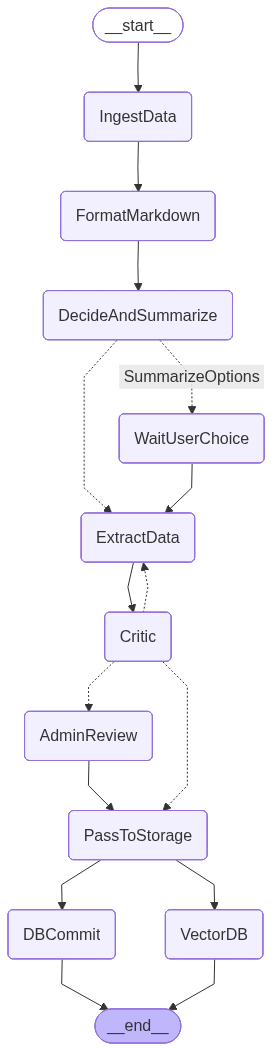

In [116]:
from IPython.display import Image, display

# 컴파일된 app의 그래프를 PNG 이미지로 렌더링하여 출력
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"그래프 렌더링 실패: {e}")

# Run

In [130]:
# 1. 실행 설정 정의
config = {"configurable": {"thread_id": "card_analysis_session_016"}}

if __name__ == "__main__":
    initial_input = {"card_id": "584", "options_list": []}
    
    # 2. invoke 호출 시 config를 함께 넘김
    # '선택' 노드에서 멈춤
    final_state = app.invoke(initial_input, config=config)
    
    # interrupt가 발생하면 여기서 실행이 멈춤.
    if final_state.get("output_json"):
        print("분석 완료!")

[Node: Ingest] 카드 ID 584 크롤링 시작...
[Node 0: Format] 원문을 마크다운 구조로 정제 중...
[Node: Decide & Summarize] 카드 타입 판단 및 요약 생성 중...
[Router] 단일 카드 상품으로 판단되었습니다. 즉시 추출을 시작합니다.
[Node: Extract] '우리 K-패스 (COOKIE CHECK)' 데이터 정밀 분석 및 JSON 생성 중...
[Node: Critic] gpt-4.1-mini 모델로 검토 중... (시도 1회)
[Router] 결함 발견(MINOR): 에이전트에게 재수정을 요청합니다.
[Node: Extract] '우리 K-패스 (COOKIE CHECK)' 데이터 정밀 분석 및 JSON 생성 중...
[Node: Critic] gpt-4.1-mini 모델로 검토 중... (시도 2회)
[Router] 시도 2회차 강제 통과. 저장 레이어로 이동.
[Node: DB Commit] 카드 '우리 K-패스 (COOKIE CHECK)'(584) DB 저장 시도...
[Node: Vector DB] '우리 K-패스 (COOKIE CHECK)' 벡터화 및 저장 시작...
DB 저장 성공: Woori Card - 우리 K-패스 (COOKIE CHECK)
[Node: Vector DB] '우리 K-패스 (COOKIE CHECK)' Vector DB 저장 완료!
분석 완료!


In [ ]:
import json

# 분석이 끝났는지 확인하고 출력
if "output_json" in final_state and final_state["output_json"]:
    print(f"[{final_state['card_name']}] 분석 완료!")
    print(json.dumps(final_state["output_json"], indent=2, ensure_ascii=False))
else:
    print("아직 결과가 생성되지 않았습니다. 로그를 확인해 주세요.")

In [126]:
from langgraph.types import Command

# 사용자가 입력하고 싶은 번호 (예: "1")
user_input = "1" 

# 멈춘 지점부터 다시 시작 (동일한 config 사용)
final_result = app.invoke(Command(resume=user_input), config=config)

# 최종 결과물 출력
if final_result.get("output_json"):
    print("\n최종 분석이 완료되었습니다!")
    import json
    print(json.dumps(final_result["output_json"], indent=2, ensure_ascii=False))

Deserializing unregistered type __main__.OptionSummary from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'OptionSummary')]
Deserializing unregistered type __main__.OptionSummary from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'OptionSummary')]
Deserializing unregistered type __main__.OptionSummary from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'OptionSummary')]



[AI 요약 리포트]
1. 옵션 1: 음식점 주중 5% / 주말 10%, 온라인 패션몰/온라인 쇼핑몰 5% 결제일 할인
2. 옵션 2: 온라인 패션몰/온라인 쇼핑몰 주중 5% / 주말 10%, 음식점 5% 결제일 할인
3. 옵션 3: 온라인 간편결제 1% 할인
1번(옵션 1)이 선택되었습니다.
[Node: Extract] '삼성 iD SELECT ON 카드 (옵션 1)' 데이터 정밀 분석 및 JSON 생성 중...
[Node: Critic] gpt-4.1-mini 모델로 검토 중... (시도 1회)
[Router] 결함 발견(CRITICAL): 에이전트에게 재수정을 요청합니다.
[Node: Extract] '삼성 iD SELECT ON 카드 (옵션 1)' 데이터 정밀 분석 및 JSON 생성 중...
[Node: Critic] gpt-4.1-mini 모델로 검토 중... (시도 2회)
[Router] 시도 2회차 강제 통과. 저장 레이어로 이동.
[Node: DB Commit] 카드 '삼성 iD SELECT ON 카드 (옵션 1)'(2886) DB 저장 시도...
[Node: Vector DB] '삼성 iD SELECT ON 카드 (옵션 1)' 벡터화 및 저장 시작...
DB 저장 성공: 삼성카드 - 삼성 iD SELECT ON 카드 (옵션 1)
[Node: Vector DB] '삼성 iD SELECT ON 카드 (옵션 1)' Vector DB 저장 완료!

최종 분석이 완료되었습니다!
{
  "card_id": "2886",
  "card_name": "삼성 iD SELECT ON 카드 (옵션 1)",
  "issuer": "삼성카드",
  "card_type": "CREDIT",
  "critical_warning": "무이자 할부 시 혜택 제외",
  "performance_logic": {
    "calculation_period": "MONTHLY",
    "global_performance_exclusion": [
      "단기카드대출(현금서

# Vector DB 저장용

In [ ]:
import os
import requests
import psycopg2
from bs4 import BeautifulSoup
from openai import OpenAI
from sshtunnel import SSHTunnelForwarder
from dotenv import load_dotenv
from server.database.connection import get_db_conn


load_dotenv()

# 1. OpenAI 클라이언트 설정
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

def get_embedding(text):
    # 최신 가성비 모델인 text-embedding-3-small 사용
    response = client.embeddings.create(
        input=text,
        model="text-embedding-3-small"
    )
    return response.data[0].embedding

def store_card_to_vector_db(card_id):
    # --- API 요청 파트 ---
    url = f"https://api.card-gorilla.com:8080/v1/cards/{card_id}"
    headers = {"User-Agent": "Mozilla/5.0", "Accept": "application/json"}
    
    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        print("API 호출 실패")
        return

    data = response.json()
    card_name = data.get("card_name") or data.get("name") or "알 수 없는 카드"

    # 1. 원문 텍스트를 모두 하나로 병합 (카드사 단서 확보용)
    all_text_for_search = ""
    for benefit in data.get("key_benefit", []):
        raw_info = benefit.get("info", "")
        soup = BeautifulSoup(raw_info, "html.parser")
        all_text_for_search += soup.get_text(separator=" ").strip() + " "

    # 2. LLM에게 추측이 아닌 '텍스트 내 팩트 추출'을 강제 지시
    print(f"원문 텍스트에서 [{card_name}]의 정확한 카드사 정보 추출 중...")
    completion = client.chat.completions.create(
        model="gpt-4.1-mini", 
        messages=[
            {
                "role": "system", 
                "content": "당신은 팩트 기반 정보 추출 전문가입니다. 제공된 신용카드 약관 텍스트를 꼼꼼히 읽고, 해당 카드를 발급한 '카드회사 이름(예: KB국민카드, 신한카드, 현대카드 등)'만 찾아내어 단답형으로 출력하세요. 이름만 보고 임의로 유추하는 것을 엄격히 금지합니다. 텍스트 내에서 증거를 찾을 수 없다면 반드시 '알 수 없는 회사'라고 출력하세요. '선택옵션' 같은 단어는 절대로 회사 이름에 포함하지 마세요."
            },
            {
                "role": "user", 
                "content": f"카드 원문 텍스트: {all_text_for_search[:3000]}" # 핵심 약관은 대부분 앞부분에 있으므로 3000자 제한으로 비용 절감
            }
        ],
        temperature=0 
    )
    card_company = completion.choices[0].message.content.strip()
    
    # 환경 변수 로드
    ssh_host = os.getenv("SSH_HOST")
    rds_host = os.getenv("RDS_HOST")

    print(f"[{card_name}] 벡터화 및 저장 시작...")

# 16개 카테고리 키워드 정의
    keywords_map = {
        "FOOD": ["음식점", "식당", "외식", "패밀리레스토랑"],
        "DELIVERY": ["배달", "배달의민족", "요기요", "쿠팡이츠"],
        "CAFE_BAKERY": ["카페", "스타벅스", "베이커리", "커피", "디저트", "투썸", "이디야", "파리바게뜨", "뚜레쥬르"],
        "MEDICAL": ["병원", "약국", "치과", "한의원", "의료", "건강검진"],
        "EDUCATION": ["학원", "교육", "학습지", "서점", "도서", "강의", "유치원"],
        "PARKING_LOT": ["주차장", "주차", "발레파킹"],
        "OIL": ["주유", "GSCALTEX", "S-OIL", "현대오일뱅크", "SK에너지", "충전소"],
        "TRANSPORTATION": ["대중교통", "버스", "지하철", "택시", "철도", "KTX", "SRT", "K-패스"],
        "TELECOM_UTILITY": ["통신", "SKT", "KT", "LGU+", "이동통신", "공과금", "관리비", "가스비", "전기요금"],
        "CONVENIENCE": ["편의점", "CU", "GS25", "세븐일레븐", "이마트24", "다이소", "올리브영"],
        "SHOPPING": ["마트", "이마트", "홈플러스", "롯데마트", "백화점", "아울렛", "쇼핑", "쿠팡", "온라인쇼핑", "오픈마켓", "11번가"],
        "CULTURE_ENTERTAINMENT": ["영화", "CGV", "메가박스", "롯데시네마", "문화", "공연", "전시", "테마파크", "놀이공원"],
        "SUBSCRIPTION": ["구독", "넷플릭스", "유튜브", "프리미엄", "디즈니플러스", "멜론", "스트리밍"],
        "OVERSEAS": ["해외", "직구", "가맹점(해외)", "아마존", "알리", "테무"],
        "TRAVEL": ["항공", "항공권", "면세점", "호텔", "숙박", "여행사", "렌터카", "야놀자", "여기어때"],
        "AIRPORT_LOUNGE": ["라운지", "공항서비스", "마티나", "스카이허브", "인천공항", "공항발레파킹", "더라운지", "라운지키"]
    }

    try:
        # SSH 터널은 한 번
        with get_db_conn() as conn:
                
                with conn.cursor() as cur:
                    for benefit in data.get("key_benefit", []):
                        title = benefit.get("title", "")
                        raw_info = benefit.get("info", "")
                        
                        # HTML 정제
                        soup = BeautifulSoup(raw_info, "html.parser")
                        clean_info = soup.get_text(separator=" ").strip()
                        
                        # 카테고리 분류 로직
                        # 1. 1차 필터링: '제외' 단어에 낚이지 않도록 혜택의 '제목(title)'에서 먼저 키워드를 찾음
                        found_categories = [
                            cat for cat, kws in keywords_map.items() 
                            if any(kw in title for kw in kws)
                        ]
                        
                        # 2. 2차 필터링: 제목에 키워드가 정 없다면, 본문(clean_info)을 검색
                        if not found_categories:
                            found_categories = [
                                cat for cat, kws in keywords_map.items() 
                                if any(kw in clean_info for kw in kws)
                            ]

                        # 3. 단일 맵핑: 파이프(|)로 묶지 않고, 발견된 것 중 1순위 대표 카테고리 딱 1개만 지정
                        final_category = found_categories[0] if found_categories else "OTHER"

                        # 벡터화 및 저장
                        full_text = f"카드명: {card_name} | 상세: {clean_info}"
                        embedding = get_embedding(full_text)

                        cur.execute("""
                            INSERT INTO card_benefit_vectors 
                            (card_id, card_company, card_name, benefit_category, content, embedding)
                            VALUES (%s, %s, %s, %s, %s, %s)
                        """, (
                            card_id, card_company, card_name, 
                            final_category, full_text, embedding
                        ))
                    
                    conn.commit()
                    print(f"[{card_name}] 저장 완료!")

    except Exception as e:
        print(f"오류 발생: {e}")

In [74]:
import os
import json
import psycopg2
from openai import OpenAI
from sshtunnel import SSHTunnelForwarder
from dotenv import load_dotenv

load_dotenv()

# 1. OpenAI 클라이언트 설정
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

def get_embedding(text):
    # 최신 가성비 모델인 text-embedding-3-small 사용
    response = client.embeddings.create(
        input=text,
        model="text-embedding-3-small"
    )
    return response.data[0].embedding

# 2. PDF에서 추출한 네이버페이 혜택 데이터 정의 (정적 데이터)
naver_pay_data = [
{
    "content": "네이버페이는 2026년 4월 1일부터 4월 20일까지 이니스프리 매장에서 포인트·머니 결제 시 5,000원 적립 혜택을 제공합니다. 네이버페이 포인트 또는 머니로 20,000원 이상 현장 결제 시 5,000원이 즉시 적립되며, 이벤트 기간 내 네이버 ID 기준 1인 1회 참여 가능합니다. 혜택 적립 여부는 네이버페이 내 [Npay 포인트] 메뉴에서 확인하실 수 있습니다.",
    "metadata": {
        "category": "cosmetics_store",
        "event_type": "limited_period",
        "payment_method": "Naver Pay (Point/Money)",
        "brands": ["이니스프리"],
        "start_date": "2026-04-01",
        "end_date": "2026-04-20",
        "benefit_max": 5000,
        "min_purchase": 20000
    }
}
]



def store_naver_pay_to_vector_db():
    print("네이버페이 데이터 벡터화 및 저장 시작...")
    
    # 환경 변수 로드
    ssh_host = os.getenv("SSH_HOST")
    rds_host = os.getenv("RDS_HOST")

    try:
        # SSH 터널 연결
        with SSHTunnelForwarder(
            (ssh_host, 22),
            ssh_username=os.getenv("SSH_USER"),
            ssh_pkey=os.getenv("SSH_KEY_PATH"),
            remote_bind_address=(rds_host, 5432)
        ) as tunnel:
            
            # DB 연결
            with psycopg2.connect(
                host='127.0.0.1',
                port=tunnel.local_bind_port,
                user=os.getenv("RDS_USER"),
                password=os.getenv("RDS_PASSWORD"),
                dbname=os.getenv("RDS_DB_NAME")
            ) as conn:
                
                with conn.cursor() as cur:
                    for item in naver_pay_data:
                        content = item["content"]
                        metadata = json.dumps(item["metadata"], ensure_ascii=False)
                        
                        # 임베딩 생성
                        print(f"임베딩 생성 중: {content[:30]}...")
                        embedding = get_embedding(content)
                        
                        # DB 삽입 (naver_pay_vectors 테이블 대상)
                        cur.execute("""
                            INSERT INTO naver_pay_vectors 
                            (content, metadata, embedding)
                            VALUES (%s, %s, %s)
                        """, (
                            content, metadata, embedding
                        ))
                    
                    conn.commit()
                    print("네이버페이 혜택 저장 완료!")

    except Exception as e:
        print(f"오류 발생: {e}")

# 함수 실행
store_naver_pay_to_vector_db()

네이버페이 데이터 벡터화 및 저장 시작...
임베딩 생성 중: 네이버페이는 2026년 4월 1일부터 4월 20일까지 ...
네이버페이 혜택 저장 완료!


In [79]:
store_card_to_vector_db("2929")




원문 텍스트에서 [KB Youth Club 체크카드]의 정확한 카드사 정보 추출 중...
[KB Youth Club 체크카드] 벡터화 및 저장 시작...
[KB Youth Club 체크카드] 저장 완료!


    {
        "content": "네이버페이는 매주 금, 토, 일요일마다 주요 편의점(GS25, CU, 세븐일레븐, 이마트24)에서 현장 결제 포인트 적립 이벤트를 진행합니다. 네이버페이 포인트 또는 머니로 2,000원 이상 현장 결제 시 일자별로 500원씩, 주말 3일 동안 총 1,500원의 포인트 적립 혜택을 받을 수 있습니다. 혜택을 받기 위해서는 매주 이벤트 페이지 하단의 '혜택 신청하기' 버튼을 반드시 클릭한 후 결제해야 합니다.",
        "metadata": {
            "category": "convenience_store",
            "event_type": "weekly_recurring",
            "payment_method": "Naver Pay",
            "brands": ["GS25", "CU", "7-ELEVEN", "emart24"],
            "benefit_max": 1500
        }
    }

    naver_pay_data = [
    {
        "content": "네이버페이는 매주 월요일부터 일요일까지 주요 10개 카페 브랜드(메가커피, 컴포즈커피, 투썸플레이스, 빽다방, 이디야, 매머드익스프레스, 더벤티, 파스쿠찌, 커피빈, 폴바셋)에서 현장 결제 포인트 적립 이벤트를 진행합니다. 네이버페이 포인트 또는 머니로 2,000원 이상 현장 결제 시 매일 500원씩, 일주일 동안 최대 3,500원의 포인트 적립 혜택을 받을 수 있습니다. 혜택을 받기 위해서는 매주 월요일 이벤트 페이지 하단의 '혜택 신청하기' 버튼을 반드시 클릭한 후 결제해야 합니다.",
        "metadata": {
            "category": "cafe",
            "event_type": "weekly_recurring",
            "payment_method": "Naver Pay",
            "brands": ["메가커피", "컴포즈커피", "투썸플레이스", "빽다방", "이디야", "매머드익스프레스", "더벤티", "파스쿠찌", "커피빈", "폴바셋"],
            "benefit_max": 3500
        }
    }
]

{
    "content": "네이버페이는 2026년 4월 1일부터 4월 30일까지 이삭토스트 매장에서 포인트·머니 결제 시 20% 적립 혜택을 제공합니다. 네이버페이 포인트 또는 머니로 5,000원 이상 현장 결제 시 혜택이 적용되며, 이벤트 기간 내 1인당 최대 10,000원까지 적립 가능합니다. 단, 일반 카드 결제 시에는 혜택 적용이 불가하며 자세한 사항은 매장 안내를 참조하시기 바랍니다.",
    "metadata": {
        "category": "food_bakery",
        "event_type": "limited_period",
        "payment_method": "Naver Pay (Point/Money)",
        "brands": ["이삭토스트"],
        "start_date": "2026-04-01",
        "end_date": "2026-04-30",
        "benefit_rate": "20%",
        "benefit_limit": 10000,
        "min_purchase": 5000
    }
}

naver_pay_data = [
{
    "content": "네이버페이는 2026년 3월 25일부터 4월 24일까지 전국 다이소 매장에서 포인트·머니 결제 시 2,000원 적립 혜택을 제공합니다. 네이버페이 포인트 또는 머니(QR 결제 및 삼성페이 포함)로 1만 5천 원 이상 현장 결제 시 혜택이 적용되며, 이벤트 기간 내 네이버 ID 기준 1인 1회 참여 가능합니다. 단, 카드 결제나 제로페이, 라인페이 결제는 제외되며 대형마트나 백화점 등에 입점한 일부 특수 매장에서는 혜택이 제공되지 않을 수 있습니다.",
    "metadata": {
        "category": "lifestyle_store",
        "event_type": "limited_period",
        "payment_method": "Naver Pay (Point/Money QR & Samsung Pay)",
        "brands": ["다이소"],
        "start_date": "2026-03-25",
        "end_date": "2026-04-24",
        "benefit_max": 2000,
        "min_purchase": 15000
    }
}
]

{
    "content": "네이버페이는 2026년 4월 1일부터 4월 20일까지 이니스프리 매장에서 포인트·머니 결제 시 5,000원 적립 혜택을 제공합니다. 네이버페이 포인트 또는 머니로 20,000원 이상 현장 결제 시 5,000원이 즉시 적립되며, 이벤트 기간 내 네이버 ID 기준 1인 1회 참여 가능합니다. 혜택 적립 여부는 네이버페이 내 [Npay 포인트] 메뉴에서 확인하실 수 있습니다.",
    "metadata": {
        "category": "cosmetics_store",
        "event_type": "limited_period",
        "payment_method": "Naver Pay (Point/Money)",
        "brands": ["이니스프리"],
        "start_date": "2026-04-01",
        "end_date": "2026-04-20",
        "benefit_max": 5000,
        "min_purchase": 20000
    }
}